2026-03-12 13:06:07.152069: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/Users/amatthews/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
3119/3119 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - accuracy: 0.5752 - loss: 0.6907 - val_accuracy: 0.6033 - val_loss: 0.6820
Epoch 2/10
3119/3119 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.5933 - loss: 0.6845 - val_accuracy: 0.5535 - val_loss: 0.6907
Epoch 3/10
3119/3119 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.5779 - loss: 0.6842 - val_accuracy: 0.5841 - val_loss: 0.6857
Epoch 4/10
3119/3119 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.5852 - loss: 0.6839 - val_accuracy: 0.5526 - val_loss: 0.6928
Epoch 5/10
3119/3119 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - accuracy: 0.5709 - loss: 0.6839 - val_accuracy: 0.5935 - val_loss: 0.6804
Epoch 6/10
3119/3119 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.5857 - loss: 0.6838 - val_accuracy: 0.5355 - val_loss: 0.6980
Epoch 7/10
3119/3119 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - accuracy: 0.5749 - loss: 0.6838 - val_accuracy: 0.5128 - val_loss: 0.7008
Epoch 8/10
3119/3119 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - accuracy: 0.5578 - loss: 0.

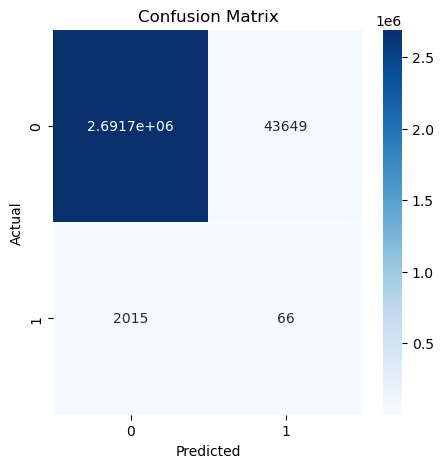


TEST RESULTS
-------------------------
Classification Report
-------------------------
              precision    recall  f1-score   support

           0       1.00      0.98      0.99   2735349
           1       0.00      0.02      0.00      2080

    accuracy                           0.98   2737429
   macro avg       0.50      0.50      0.50   2737429
weighted avg       1.00      0.98      0.99   2737429



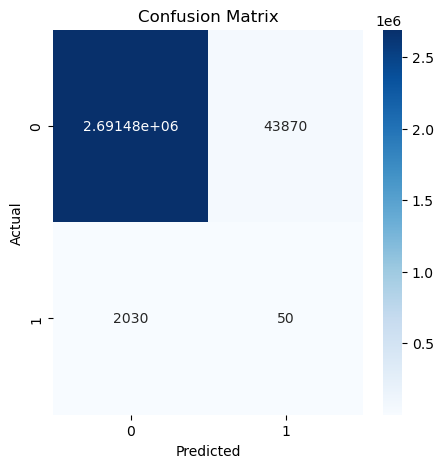

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf

# -----------------------------
# 1. Load Data
# -----------------------------

MODIS_FIRMS_TRAIN_VAL_TEST_DATASET = '../data/processed/modis_firms_train_val_test_dataset.npz'
data = np.load(MODIS_FIRMS_TRAIN_VAL_TEST_DATASET)

X_train = data["X_train"]
y_train = data["y_train"]
X_val = data["X_val"]
y_val = data["y_val"]
X_test = data["X_test"]
y_test = data["y_test"]

# -----------------------------
# 2. Standard Scaler
# -----------------------------

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype(np.float32))
X_val_scaled = scaler.transform(X_val.astype(np.float32))
X_test_scaled = scaler.transform(X_test.astype(np.float32))

# -----------------------------
# 3. Class weights for imbalance
# -----------------------------

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {0: float(class_weights[0]), 1: float(class_weights[1])}

# -----------------------------
# 4. Train Logistic Regression Model
# -----------------------------

model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation='sigmoid', input_shape=(X_train_scaled.shape[1],))
])
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_scaled,
    y_train.astype(np.float32),
    validation_data=(X_val_scaled, y_val.astype(np.float32)),
    epochs=10,
    batch_size=4096,
    class_weight=class_weight_dict,
    verbose=1
)

# -----------------------------
# 5. Evaluate Function
# -----------------------------

def evaluate_model(model, X, y_true, threshold=None):
    """
    Evaluate logistic regression predictions with optional thresholding.
    Plots confusion matrix and prints classification report.
    Returns predictions.
    """
    # Predict probabilities
    y_prob = model.predict(X, verbose=0).flatten()
    
    # Determine threshold if not provided
    if threshold is None:
        precision_vals, recall_vals, thresholds = precision_recall_curve(y_true, y_prob)
        f1_scores = 2 * (precision_vals * recall_vals) / (precision_vals + recall_vals + 1e-8)
        optimal_idx = np.argmax(f1_scores)
        threshold = thresholds[optimal_idx]
        print(f"Optimal Threshold determined: {threshold:.4f}")
    
    # Apply threshold
    y_pred = (y_prob >= threshold).astype(int)
    
    cnf_matrix = confusion_matrix(y_true, y_pred)    
    print("-"*25)
    print("Classification Report")
    print("-"*25)
    print(classification_report(y_true, y_pred))
    
    plt.figure(figsize=(5,5))
    sns.heatmap(cnf_matrix, annot=True, fmt="g", cmap=plt.cm.Blues)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()
    
    return y_pred, threshold

# -----------------------------
# 6. Evaluate on Validation and Test Sets
# -----------------------------

print("\nVALIDATION RESULTS")
y_val_pred, optimal_threshold = evaluate_model(model, X_val_scaled, y_val)

print("\nTEST RESULTS")
y_test_pred, _ = evaluate_model(model, X_test_scaled, y_test, threshold=optimal_threshold)